# Visualization & Analysis of Bayesian Optimization on SPVVVECTR

*importing modules*

In [114]:
import pandas as pd
import matplotlib.pyplot as plt
from skopt import load
from skopt.plots import plot_objective

*modular function to plot observations for each experiment*

In [115]:
def plot_scatter(csv_filepath, title="SPVVVECTR Observed Trials"):
    """
    Loads BO trial data from CSV and outputs 3d scatter plot.
    Fitness (displacement) is represented by both color (heat) and marker size
    """

    df = pd.read_csv(csv_filepath, nrows=50)

    # setup 3d figure
    fig = plt.figure(figsize=(10, 8))
    ax = fig.add_subplot(111, projection='3d')

    # create 4d scatter plot
    scatter = ax.scatter(
        df['RPM_1'],
        df['RPM_2'],
        df['RPM_3'],
        c=df['Displacement_mm'] if 'Displacement_mm' in df.columns else df['Displacement_mm_mean'],
        cmap='inferno',
        s=df['Displacement_mm'] if 'Displacement_mm' in df.columns else df['Displacement_mm_mean'] * 0.8, # scaled size of points 
        alpha=0.8,
        edgecolors='w',
        linewidth=0.5
    )

    # format and label
    ax.set_xlabel('Strut 1 (RPM)', labelpad=10)
    ax.set_ylabel('Strut 2 (RPM)', labelpad=10)
    ax.set_zlabel('Strut 3 (RPM)', labelpad=10)
    ax.set_title(title, pad=20, fontsize=14)

    # legend for fitness
    cbar = fig.colorbar(scatter, ax=ax, shrink=0.5, pad=0.1)
    #if 'Displacement_mm' in df.columns:
    cbar.set_label('Displacement (mm)', rotation=270, labelpad=20)
    #else:
        #cbar.set_label('Mean Displacement (mm) (n=3)', rotation=270, labelpad=20)

    plt.tight_layout()
    plt.show()

*modular function to plot partial dependence for each experiment*

In [116]:
def plot_partial_dependence(pkl_filepath, title):
    """
    Loads a saved BO model (.pkl) and generates 
    a 2d partial dependence matrix plot for all 3 parameters (RPM_1, RPM_2, RPM_3).
    """

    res = load(pkl_filepath)
    dim_names = ['Strut 1 (RPM)', 'Strut 2 (RPM)', 'Strut 3 (RPM)']

    plot_objective(
        res,
        sample_source='result',
        minimum=res.x, #red star is best phyiscal gait observed
        dimensions=dim_names,
    )

    fig = plt.gcf()
    fig.set_size_inches(12, 12)

    plt.subplots_adjust(wspace=0.4, hspace=0.4)

    for current_ax in fig.axes:
        current_ax.tick_params(axis='x', rotation=45)

    fig.suptitle(f"{title}", fontsize=18, y=0.98)

    plt.show()




*method that outputs the top 5 best rpm combinations that each experiment found*

In [117]:
import pandas as pd

def print_top_5_gaits(csv_filepath, experiment_name="Experiment"):
    """
    Reads a Bayesian Optimization CSV, finds the top 5 highest displacements,
    and prints them as a clean, aligned text table suitable for a code block.
    """
    # 1. Load only the 50 trial rows to avoid the summary block at the bottom
    df = pd.read_csv(csv_filepath, nrows=50)
    
    # 2. Sort by displacement in descending order (highest to lowest)
    if 'Displacement_mm' in df.columns:
        top_5 = df.sort_values(by="Displacement_mm", ascending=False).head(5)
    else:
        top_5 = df.sort_values(by="Displacement_mm_mean", ascending=False).head(5)

    # 3. Print the Title
    print(f"    Top 5 Best Gaits: {experiment_name}")
    
    # 4. Print the aligned header
    header = f"{'Rank':<5} | {'Phase':<13} | {'Strut 1':<8} | {'Strut 2':<8} | {'Strut 3':<8} | {'Displacement (mm)':<17}"
    print(header)
    print("-" * len(header))
    
    # 5. Iterate through the top 5 and print aligned rows
    rank = 1
    for index, row in top_5.iterrows():
        phase = row['Phase']
        rpm1 = int(row['RPM_1'])
        rpm2 = int(row['RPM_2'])
        rpm3 = int(row['RPM_3'])
        if 'Displacement_mm' in row:
            disp = f"{row['Displacement_mm']:.2f}"
        else:
            disp = f"{row['Displacement_mm_mean']:.2f}"

        # The :< number forces the text to take up exactly that many spaces
        print(f"{rank:<5} | {phase:<13} | {rpm1:<8} | {rpm2:<8} | {rpm3:<8} | {disp:<17}")
        rank += 1
        

*method that outputs the convergence plot comparing all 3 experiments*

In [118]:
def plot_convergence():
    # file paths
    experiments = {
        "Random Priors": "../../SPVVVECTR_DATA/bo_experiment_SPVVVECTR-1a/bo_results_random_priors/bo_results_20260728_141100.csv",
        "LHS Priors": "../../SPVVVECTR_DATA/bo_experiment_SPVVVECTR-1a/bo_results_lhs_priors/bo_results_20260728_143448.csv",
        "No Priors": "../../SPVVVECTR_DATA/bo_experiment_SPVVVECTR-1a/bo_results_no_priors/bo_results_20260728_150129.csv"
    }

    plt.figure(figsize=(10, 6))

    for label, filepath in experiments.items():
        df = pd.read_csv(filepath, nrows=50)
        
        df['Best_So_Far'] = df['Displacement_mm'].cummax()
        plt.plot(df['Trial_Number'], df['Best_So_Far'], label=label, marker='o', markersize=4)

    # formatting
    plt.xlabel('Trial Number', fontsize=12)
    plt.ylabel('Best Displacement (mm)', fontsize=12)
    plt.title('Bayesian Optimization Convergence', fontsize=14, pad=15)

    # legend
    plt.legend(loc="upper left")
    plt.grid(True, linestyle='-', alpha=0.7)

    plt.tight_layout()
    plt.show()

# Experiment 1: Random Priors

## Observed gaits 
3 dimensions for each strut RPM, where fitness (displacement) is represented by color.

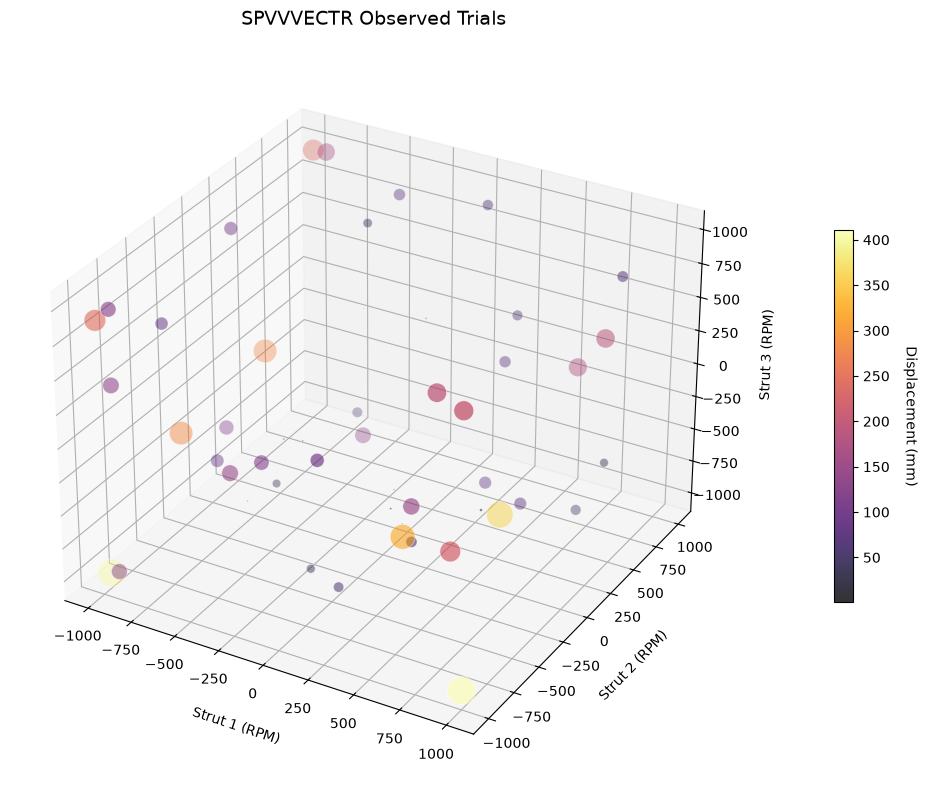

    Top 5 Best Gaits: Experiment
Rank  | Phase         | Strut 1  | Strut 2  | Strut 3  | Displacement (mm)
--------------------------------------------------------------------------
1     | Optimization  | 1000     | -1000    | -1000    | 410.76           
2     | Optimization  | -974     | -970     | -991     | 404.64           
3     | Optimization  | 789      | -252     | -331     | 364.35           
4     | Prior         | 592      | -844     | -154     | 318.03           
5     | Optimization  | -847     | -508     | -196     | 282.12           


In [119]:
path='./../../SPVVVECTR_DATA/bo_experiment_SPVVVECTR-1a/bo_results_random_priors/bo_results_20260728_141100.csv'
plot_scatter(path)
print_top_5_gaits(path)

The top 5 best rpm-combinations for this experiment are printed below:

## Partial Dependency Plot
insert explanation here

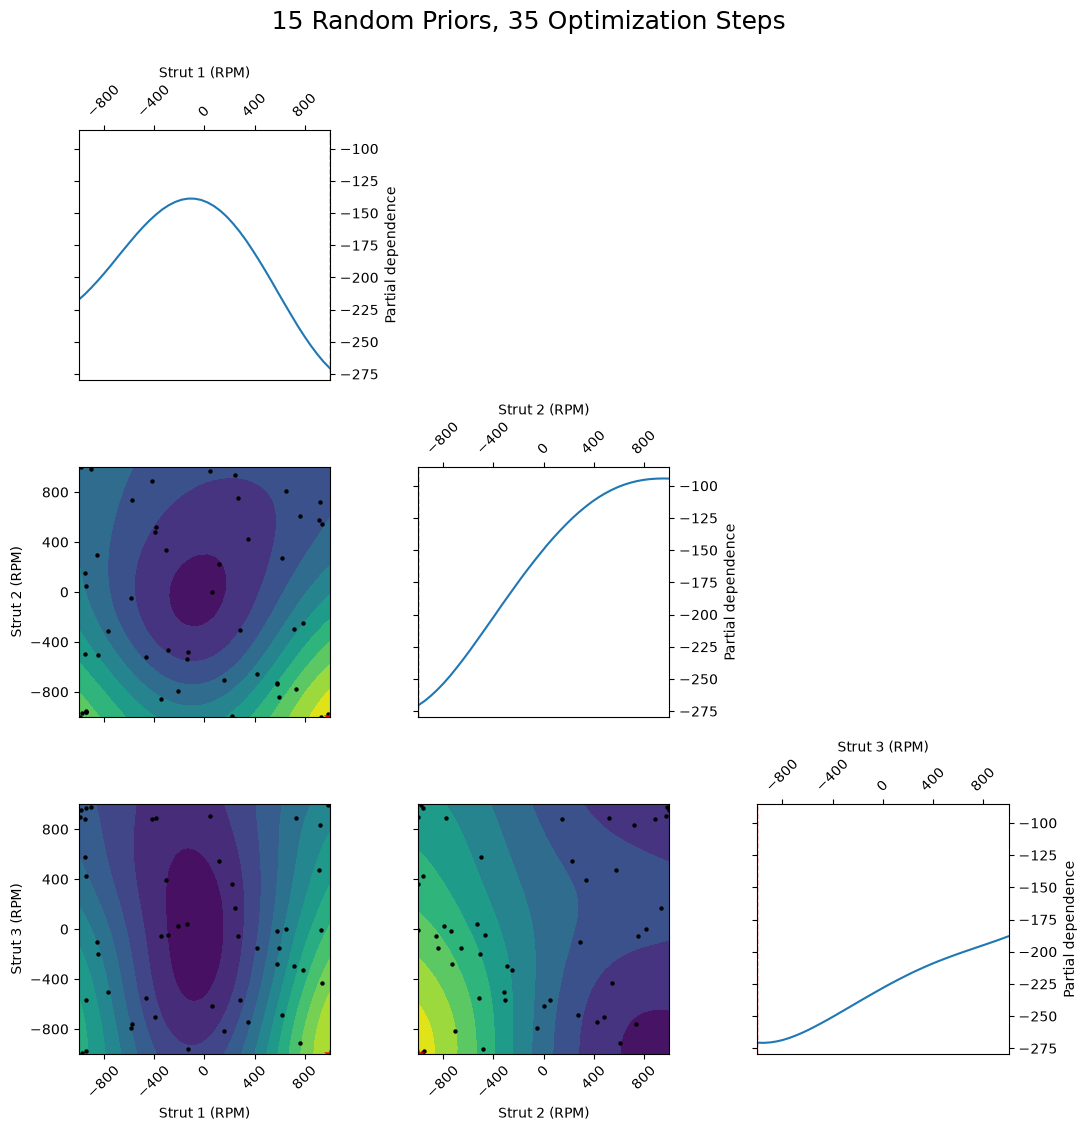

In [120]:
plot_partial_dependence('./../../SPVVVECTR_DATA/bo_experiment_SPVVVECTR-1a/bo_results_random_priors/bo_model_20260728_141100.pkl', title="15 Random Priors, 35 Optimization Steps")

# Experiment 2: Latin Hypercube Sampling Priors

## Observed gaits 
3 dimensions for each strut RPM, where fitness (displacement) is represented by color.

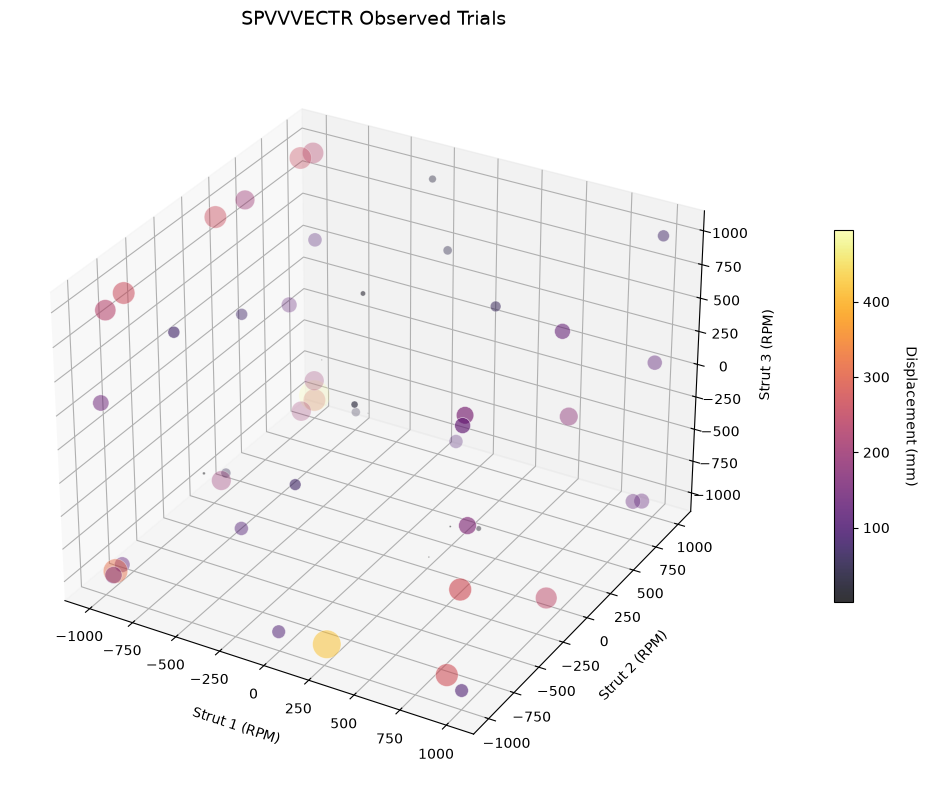

    Top 5 Best Gaits: Experiment
Rank  | Phase         | Strut 1  | Strut 2  | Strut 3  | Displacement (mm)
--------------------------------------------------------------------------
1     | Optimization  | -1000    | 1000     | -963     | 495.06           
2     | Optimization  | 258      | -989     | -989     | 419.55           
3     | Optimization  | -964     | -963     | -974     | 310.05           
4     | Optimization  | 979      | -987     | -269     | 268.92           
5     | Optimization  | 911      | -984     | -936     | 268.06           


In [121]:
path = '../../SPVVVECTR_DATA/bo_experiment_SPVVVECTR-1a/bo_results_lhs_priors/bo_results_20260728_143448.csv'
plot_scatter(path)
print_top_5_gaits(path)

## Partial Dependency Plot
insert explanation here

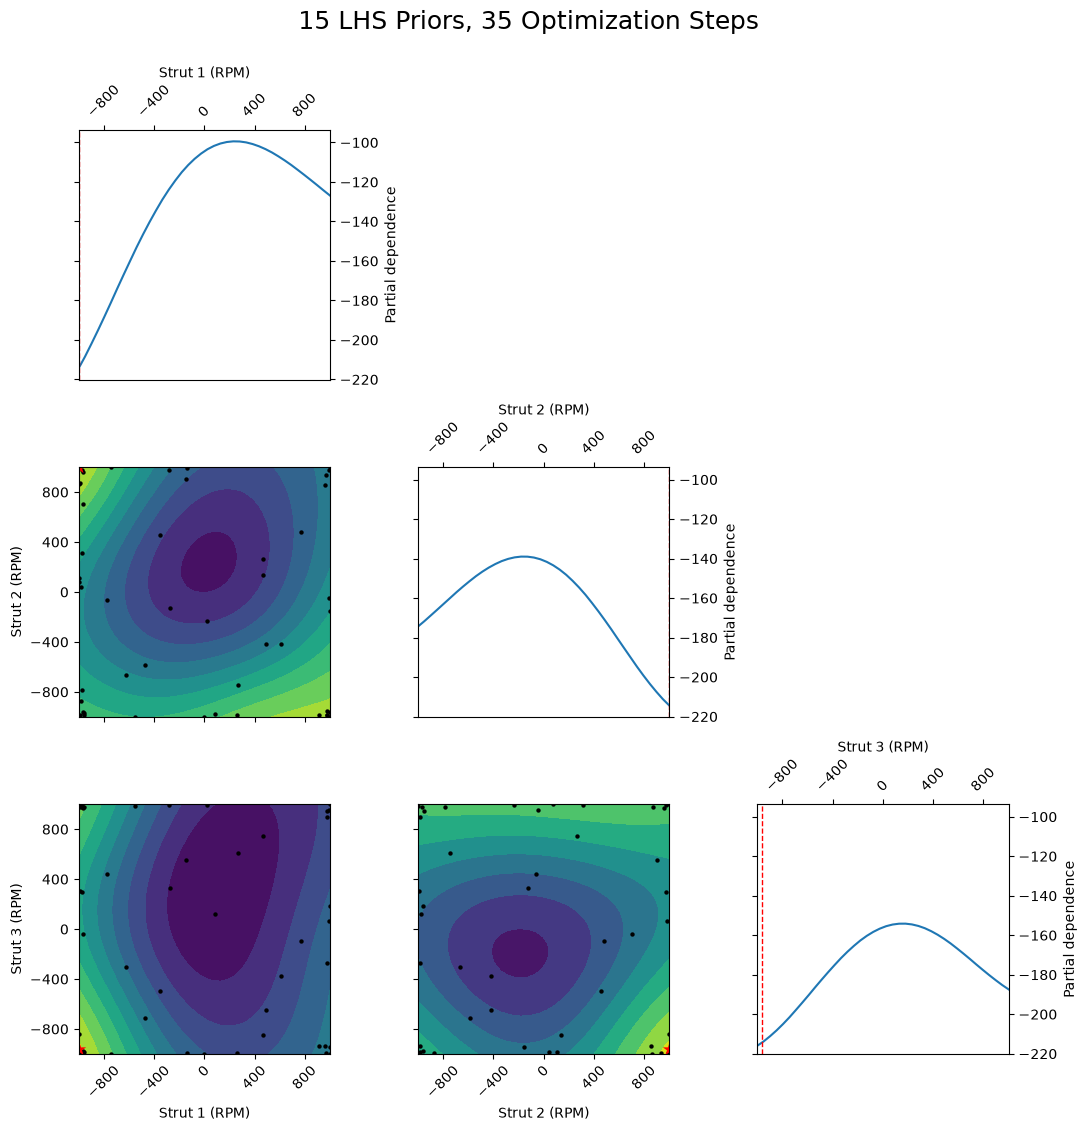

In [122]:
plot_partial_dependence('../../SPVVVECTR_DATA/bo_experiment_SPVVVECTR-1a/bo_results_lhs_priors/bo_model_20260728_143448.pkl', title="15 LHS Priors, 35 Optimization Steps")

# Experiment 3: No Priors

## Observed gaits 
3 dimensions for each strut RPM, where fitness (displacement) is represented by color.

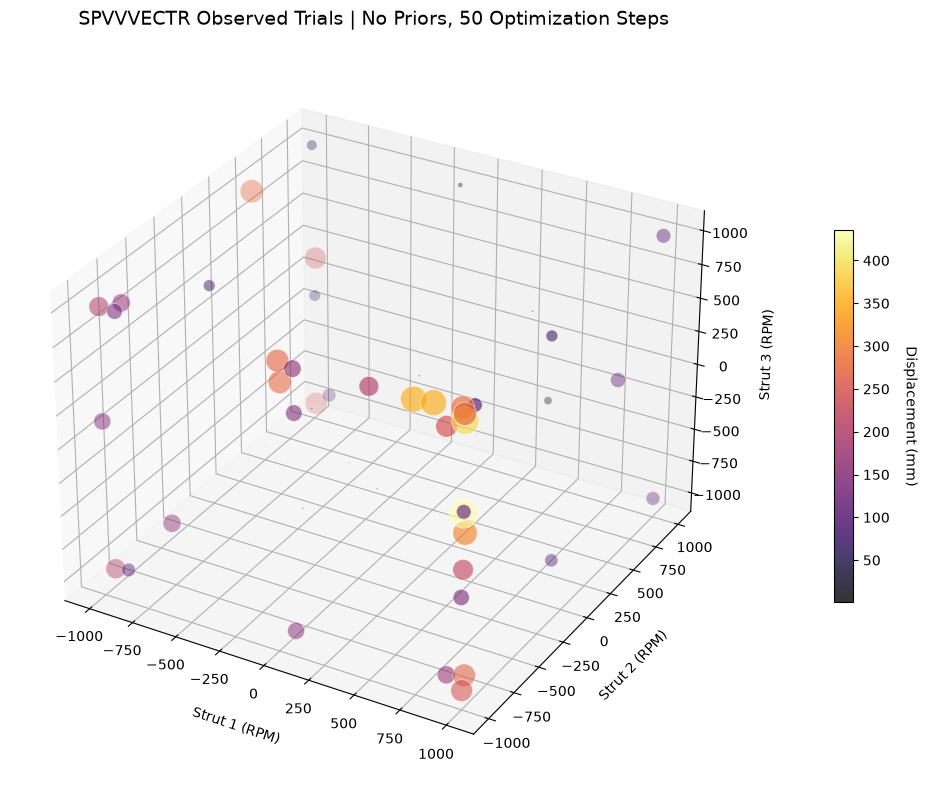

    Top 5 Best Gaits: Experiment
Rank  | Phase         | Strut 1  | Strut 2  | Strut 3  | Displacement (mm)
--------------------------------------------------------------------------
1     | Optimization  | 1000     | -1000    | 297      | 435.57           
2     | Optimization  | 993      | -984     | 939      | 395.49           
3     | Optimization  | 734      | -1000    | 1000     | 352.87           
4     | Optimization  | 828      | -983     | 1000     | 351.37           
5     | Optimization  | 997      | -980     | 143      | 305.52           


In [123]:
path = '../../SPVVVECTR_DATA/bo_experiment_SPVVVECTR-1a/bo_results_no_priors/bo_results_20260728_150129.csv'
plot_scatter(path, title="SPVVVECTR Observed Trials | No Priors, 50 Optimization Steps")
print_top_5_gaits(path)

## Partial Dependency Plot
insert explanation here

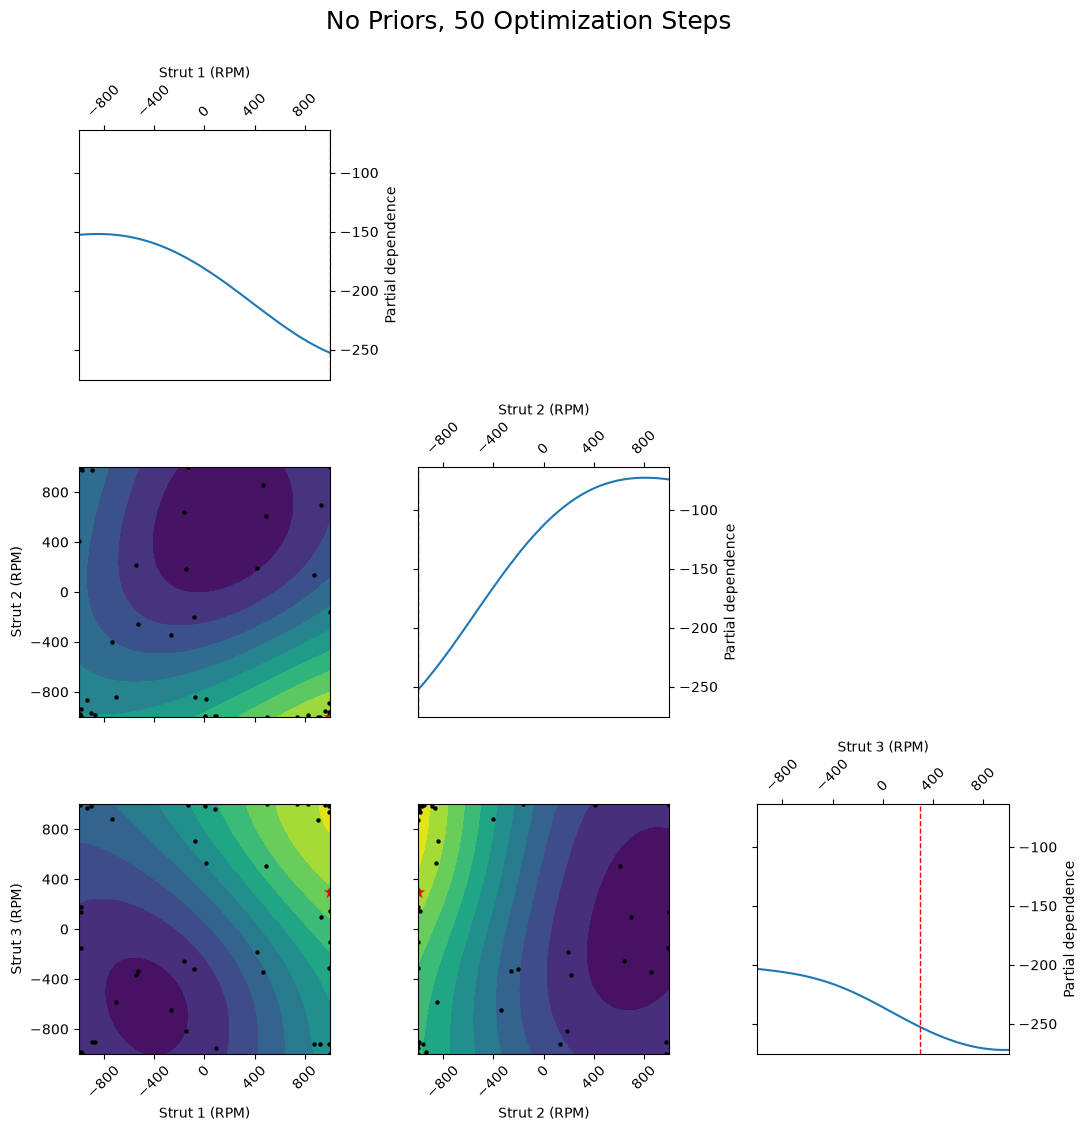

In [124]:
plot_partial_dependence('../../SPVVVECTR_DATA/bo_experiment_SPVVVECTR-1a/bo_results_no_priors/bo_model_20260728_150129.pkl', title="No Priors, 50 Optimization Steps")

# Convergence Plot 
Each experiments max fitness, and how long it took each one to get there 

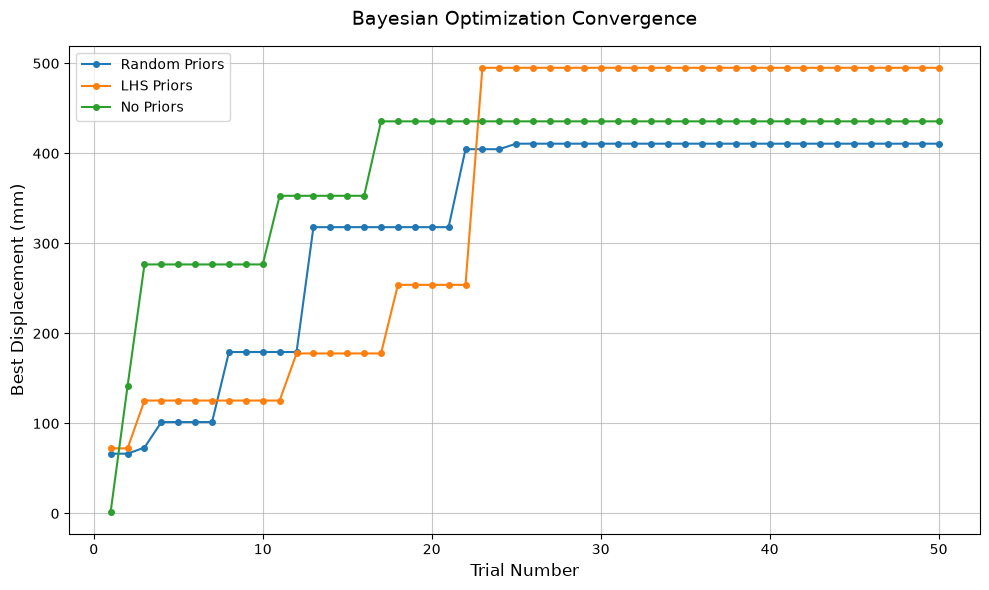

In [125]:
plot_convergence()

## Conclusion from Experiments 1-3
* LHS Priors lead to the most comprehensive search of the parameter-space by the nature of splitting into sections, and taking points from each section. Although this means a lagged start, it is intentionally testing 'bad' points to get a lay of the land before narrowing down into the points for optimization steps. This results in greater context for the optimizer for the parameter-space, and in our experiment, resulted in greater max displacement found. 

* On the other hand, no priors led the optimizer to explore deeply into a local maxima without much regard to the rest the search space, resulting in many gaps. This led to quick initial gains, but a plateau after 15 trials, once the local maxima was exhausted. 


*Note that there are high levels of variance due to the unpredictable nature of vibrational based locomotion. This experiment found generally what are the best gaits for actuating high levels of linear displacement over the course of 20 second trials on a flat surface.

## Hypothesis
### If the frequency of the motors matches the natural frequency of the tensegrity, then the tensegrity begins to resonate, causing much more movement and displacement. Therefore, what if the BO Algorithm, in attempting to find displacement-maximizing gaits, inadvertently found gaits that matched the natural frequency of the robot? 

### next steps: Finding the natural frequency of SPVVVECTR

# August 3rd Experiments
* Run LHS experiment 3 times, for SPVVVECTR-1b (150 experiments) - achieve 2 things:
    * Important to increase sample size (n=3) instead if n=1 because of output variance. We will consider averages to determine fittest gaits. 
    * Testing the effectivness of SPVVVECTR-1b, which features heavier and bigger cables


<br>

* run top 3 highest fittest gaits (g_best1, g_best2, g_best3) 30 times each w/ variance testing 
    * Same reason in order to increase sample size to n=10 to factor in noise

<br>

* extend max gait, g_max = [1000, 1000, 1000], variance testing to n=30 to test whether BO outputted a gait that performs better than just the highest frequency gait 
    * as we know already that higher frequency gaits map to higher displacements, this is to validate the effectiveness of BO 


### LHS BO Results for SPVVVECTR-1b; scatter plot for mean displacement (n=3)

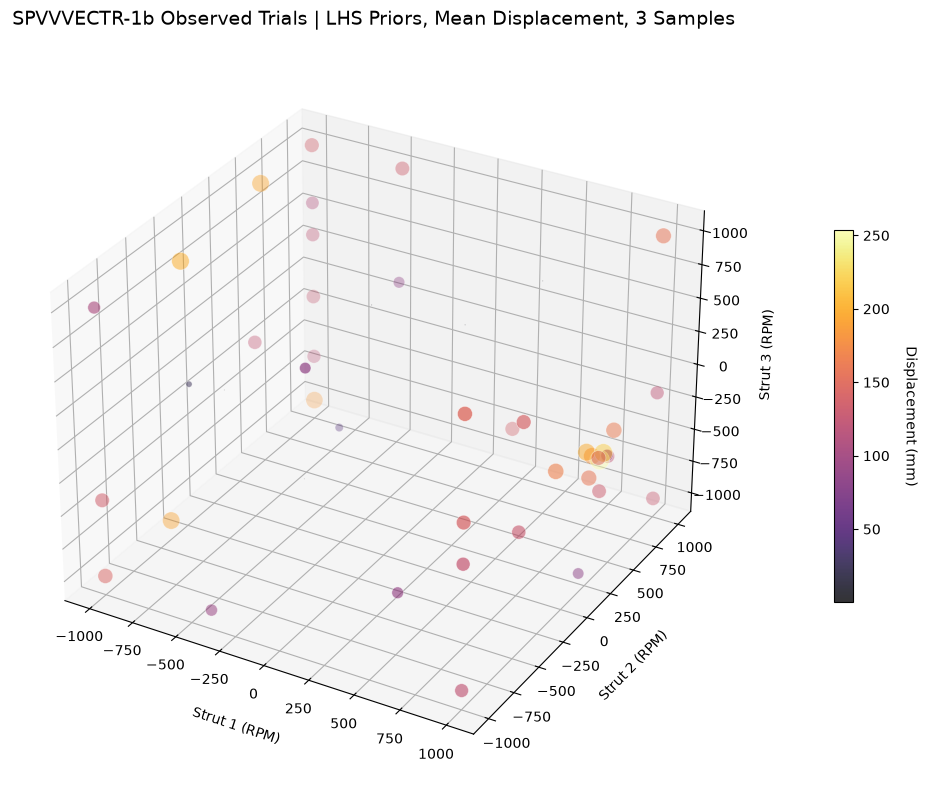

    Top 5 Best Gaits: SPVVVECTR-1b Observed Trials | LHS Priors, Mean Displacement, 3 Samples
Rank  | Phase         | Strut 1  | Strut 2  | Strut 3  | Displacement (mm)
--------------------------------------------------------------------------
1     | Optimization  | 982      | 414      | -301     | 253.66           
2     | Optimization  | 1000     | 417      | -243     | 219.93           
3     | Prior         | -914     | -379     | 981      | 200.49           
4     | Optimization  | 924      | 384      | -245     | 197.90           
5     | Optimization  | -1000    | 501      | 1000     | 194.13           


In [126]:
path = './../../SPVVVECTR_DATA/bo_experiment_SPVVVECTR-1b/lhs/experiment1_8-3-26/initial_lhs_test_meaned_displacement/lhs_3_samples_meaned_OCCASIONAL_REPOSITIONING.csv'
plot_scatter(path, title="SPVVVECTR-1b Observed Trials | LHS Priors, Mean Displacement, 3 Samples")
print_top_5_gaits(path, "SPVVVECTR-1b Observed Trials | LHS Priors, Mean Displacement, 3 Samples")

# August 4th Experiment Results

### Scatter plot for LHS BO with constant starting point & Orientation for every Trial:

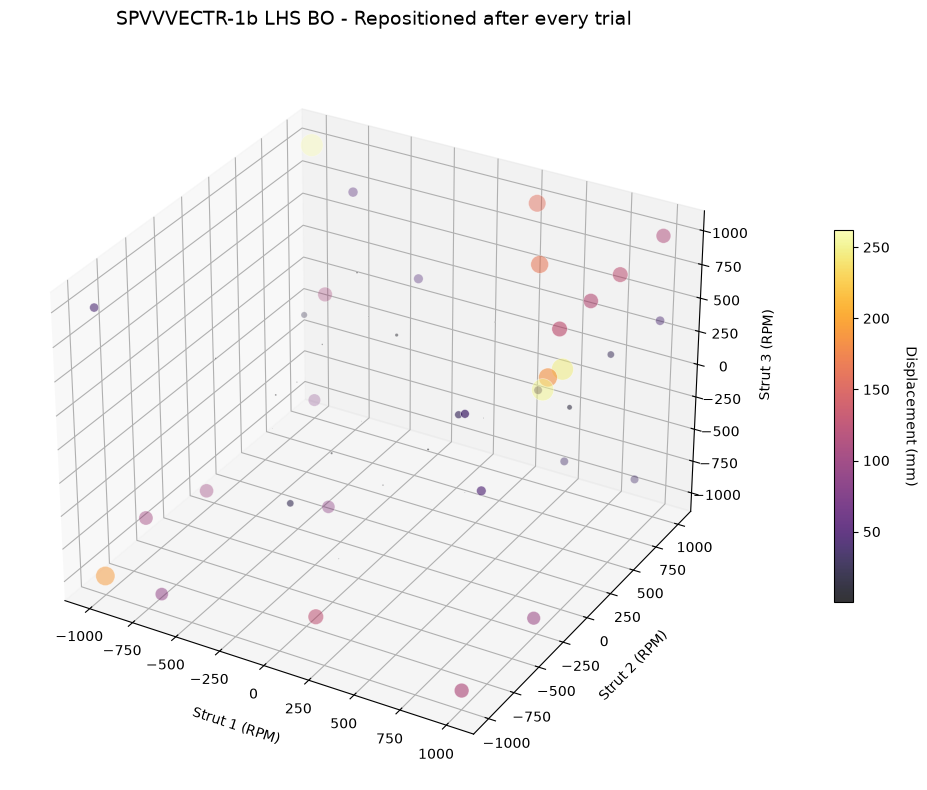

    Top 5 Best Gaits: Experiment
Rank  | Phase         | Strut 1  | Strut 2  | Strut 3  | Displacement (mm)
--------------------------------------------------------------------------
1     | Optimization  | -1000    | 1000     | 1000     | 262.07           
2     | Prior         | 886      | -24      | 479      | 254.78           
3     | Optimization  | 907      | 136      | 532      | 248.75           
4     | Optimization  | -1000    | -1000    | -1000    | 191.13           
5     | Optimization  | 879      | 41       | 523      | 184.58           


In [129]:
path = './../../SPVVVECTR_DATA/bo_experiment_SPVVVECTR-1b/lhs/experiment2_8-4-26/lhs_bo_testing/lhs_bo_repositioning.csv'
plot_scatter(path, "SPVVVECTR-1b LHS BO - Repositioned after every trial")
print_top_5_gaits(path)

**top 3 non vertex gaits:**
1. `[886, -24, 479]`
2. `[907, 136, 532]`
3. `[879, 41, 523]`